# Modeling solar power yield in Python

This tutorial demonstrates how to estimate the power output of a photovoltaic (PV) system using the [pvlib-python](https://pvlib-python.readthedocs.io/) library.


The first step is to import a few Python pacakges.

In [ ]:
# Install pvlib in Google Colab as this is not a standard package.
!pip install pvlib

In [1]:
import pvlib  # library for PV and solar calculations
import pandas as pd  # library for data analysis
import matplotlib.pyplot as plt  # library for plotting
import numpy as np  # library for math and linear algebra

## Step 1: Define a location

A location is defined by a latitude and longitude according to the convention of [ISO 6709](https://en.wikipedia.org/wiki/ISO_6709). Specifically, latitude is in degrees north of the equator and the longitude is in degrees east of the prime meridian.

👉 Update the coordinates to specify Sisimiut.

In [3]:
latitude = 64.17
longitude = -51.73

## Step 2: Retrieve irradiance data from NASA POWER

In this step, irradiance time series data is retrieved from the NASA POWER [dataset](https://power.larc.nasa.gov/data-access-viewer/) using the pvlib function [``get_nasa_power``](https://pvlib-python.readthedocs.io/en/latest/reference/generated/pvlib.iotools.get_nasa_power.html).

👉 Simply execute this cell without making any changes.

In [56]:
# Define start and end date
start = "2025-01-01"
end = "2025-12-31"

parameters = parameters=['dni', 'dhi', 'ghi', 'temp_air', 'wind_speed', 'ALLSKY_SRF_ALB']

data, meta = pvlib.iotools.get_nasa_power(
    latitude, longitude, start, end, parameters)

# Rename and interpolate albedo values
data = data.rename(columns={'ALLSKY_SRF_ALB': 'albedo'})
data["albedo"] = data["albedo"].interpolate().bfill()

# Shift the timestamp to be in the middle of the hour
data.index = data.index + pd.Timedelta(minutes=30)

data

,dni,dhi,ghi,temp_air,wind_speed,albedo
2025-01-01 00:30:00+00:00,0.0,0.0,0.0,-9.42,2.30,0.45
2025-01-01 01:30:00+00:00,0.0,0.0,0.0,-9.26,2.37,0.45
2025-01-01 02:30:00+00:00,0.0,0.0,0.0,-9.19,2.57,0.45
2025-01-01 03:30:00+00:00,0.0,0.0,0.0,-9.14,2.97,0.45
2025-01-01 04:30:00+00:00,0.0,0.0,0.0,-9.13,3.41,0.45
...,...,...,...,...,...,...
2025-12-31 19:30:00+00:00,0.0,0.0,0.0,1.01,6.92,0.45
2025-12-31 20:30:00+00:00,0.0,0.0,0.0,0.91,7.24,0.45
2025-12-31 21:30:00+00:00,0.0,0.0,0.0,0.84,7.42,0.45
2025-12-31 22:30:00+00:00,0.0,0.0,0.0,0.81,7.53,0.45


## Step 3: Calculate solar position

Once we have defined a location and the time stamps for which we want to calculate solar position for, we can use the function ``pvlib.solarposition.get_solarposition`` to calculate the solar positions. You can find the documentation for the function [here](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.solarposition.get_solarposition.html#pvlib.solarposition.get_solarposition).

👉 Execute the cell without making changes.

In [ ]:
solarposition = pvlib.solarposition.get_solarposition(
    time=data.index,
    latitude=latitude,
    longitude=longitude,
)

solarposition

,apparent_zenith,zenith,apparent_elevation,elevation,azimuth,equation_of_time
2025-01-01 00:30:00+00:00,129.406014,129.406014,-39.406014,-39.406014,302.460063,-3.448683
2025-01-01 01:30:00+00:00,134.316615,134.316615,-44.316615,-44.316615,319.820392,-3.468400
2025-01-01 02:30:00+00:00,137.629727,137.629727,-47.629727,-47.629727,339.151120,-3.488108
2025-01-01 03:30:00+00:00,138.817623,138.817623,-48.817623,-48.817623,359.849324,-3.507807
2025-01-01 04:30:00+00:00,137.656043,137.656043,-47.656043,-47.656043,20.556789,-3.527496


## Step 4: Calculate irradiance on the module surface

In this step, the standard irradiance components (GHI, DHI, and DNI) are used to estimate irradiace on a the module surface.

This is done using the pvlib-python function [``get_total_irradiance``](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.irradiance.get_total_irradiance.html).

👉 Updte the surface tilt and surface azimuth angles to specify a south facing surface with a tilt of 50 degrees.

*Hint: remember that azimuth angles are measured clockwise from north.*

In [62]:
surface_tilt =  # update this value
surface_azimuth =   # update this value

# Calculate time series of irradiance outside the Earth's atmosphere
data["dni_extra"] = pvlib.irradiance.get_extra_radiation(data.index)

# Calculate tilted irradiance
irradiance = pvlib.irradiance.get_total_irradiance(
    surface_tilt=surface_tilt,
    surface_azimuth=surface_azimuth,
    solar_zenith=solarposition['zenith'],
    solar_azimuth=solarposition['azimuth'],
    dni=data['dni'],
    ghi=data['ghi'],
    dhi=data['dhi'],
    dni_extra=data["dni_extra"],
    albedo=data["albedo"],
    model="perez",
)

# Print tilted irradiance value in kWh for the entire year
irradiance.sum()*10**-3

poa_global            1309.059360
poa_direct             691.453777
poa_diffuse            617.605583
poa_sky_diffuse        559.195930
poa_ground_diffuse      58.409652
dtype: float64

## Step 5: Estimate module temperature

Accounting for the effect of module temperature is second most important characteristic determining PV efficiency. In this exercise we will use the SAPM model for estimating the temperature of a PV panel. The model accounts for irradiance, ambient air temperature, and wind speed.

👉 Look at the [documentation](https://pvlib-python.readthedocs.io/en/stable/reference/generated/pvlib.temperature.sapm_cell.html), determine the coefficients ``a`` and ``b`` for a roof top system (closed mount) with a glass/glass module.

Text(0, 0.5, 'Tilted irradiance [kWh]')

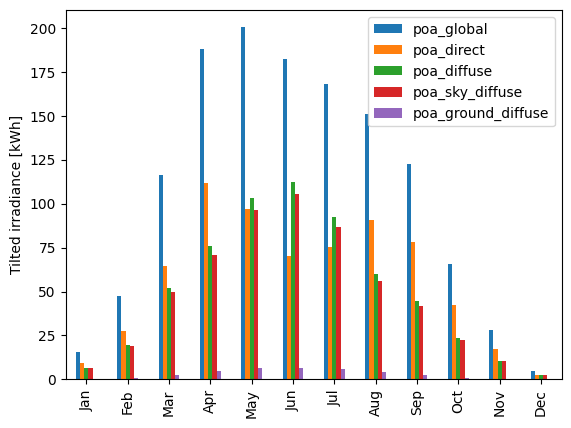

In [ ]:
temp_cell = pvlib.temperature.sapm_cell(
    poa_global=irradiance["poa_global"],
    temp_air=data["temp_air"],
    wind_speed=data["wind_speed"],
    a=,  # fill in the value for this coefficient
    b=,  # fill in the value for this coefficient
    deltaT=,  # fill in the value for this coefficient
)

## Step 6: Visualize the module temperature

👉 Create a scatter plot where the cell temperature is on the y-axis (``temp_cell``) and the ambient air temperautre (``data["temp_air"]``) is on the x-axis.

What do you noticed about this plot?

*Hint: you can use ``plt.scatter(x, y)`` to make a scatter plot.*

In [ ]:
# Write your code here


## Step 7: Estimate PV power

Once the module temperature and incident irradiance has been estimated, we can estimate PV power!

In this tutorial, we'll use the simple PVWatts model as shown below.

👉 Fill in the PV panel power value from the panel in the classroom. Determine what the annual PV power generation would be in kWh for the single panel.

In [ ]:
dc_power =  # nominal panel power in watts
pdc0 = -0.003 # temperature coefficient

power = pvlib.pvsystem.pvwatts_dc(
    effective_irradiance=irradiance["poa_global"],
    temp_cell=temp_cell,
    pdc0=-0.003,
    gamma_pdc=dc_power,
)

power

In [ ]:
# Write your code here